> **Authorship and purpose.** This notebook is based on exercises, instructions, theoretical background, and a notebook framework created by my internship supervisor, **Andreas W. Neitzel**, for the IAstro Summer Internship 2025. The exercise prompts and supplied setup belong to him. The worked solution code, figures, and interpretation sections are my responses to those exercises, unless a cell explicitly says otherwise. I used this practice notebook to learn how to process simulated galaxy data and to become familiar with galactic archaeology and stellar properties. It is an educational analysis, not an independent research result.

# IAstro Summer Internship 2025

Welcome to the IAstro Summer Intership 2025! This is a 3 week internship in which you will receive a theoretical introduction to Galactic archaeology and a hands-on practical project using synthetic data obtained from a simulated galaxy. Please read the following steps carefully and good luck!

\- Andreas W. Neitzel

---


## Step 0: Data Acquisition and Package Installation


### Data Format

You will be operating with data in the Hierarchical Data Format version 5 (HDF5). This format supports large, complex, heterogenous data. HDF5 uses a "file directory"-like structure that allows you to organize data within a single file in many structured ways, as you might do with files on your computer. It also allows for the embedding of metadata, i.e., data which describes the data. This makes it useful to store and organize large quantities of data. If you wish to learn more you may check the HDF Group website:
- https://www.hdfgroup.org/solutions/hdf5/


### Python Package Installation

To manipulate the data you will require the following Python packages: **yt** and **h5py**.

- **yt**: An open-source, community-developed analysis and visualization toolkit for volumetric data.
- **h5py**: A Pythonic interface to the HDF5 binary data format.

You can find their documentation here:
- https://yt-project.org/doc/index.html
- https://docs.h5py.org/en/stable/

To install, please type the following command lines in your Python work environment:

    python -m pip install --upgrade pip
    python -m pip install --user yt
    python -m pip install --user h5py

If you are having problem with the installation and/or running of the packages, make sure that the version you are installing is compatible with the Python version in your work environment. To check your Python version just write the following command line:

    python -V

It is presumed that you also have installed, and are familiar with, popular Python packages that will be of use in your coding. E.g. **numpy** and **matplotlib**. These are indispensible for any student of Physics. Consider using **hist2d** instead **scatter** when plotting data with a lot of data points.


### Synthetic Galaxy Download

The data you will be working with comes from the Feedback In Realistic Environments 2 (FIRE-2) simulations. In these simulations a miniature university was initialized and evolved following a zero-curvature ($k=0$) $\Lambda$CDM cosmological model. You will not download the entire universe, but rather a single snapshot at present redshift ($z=0$) in which the galaxy of interest is located. The galaxy of interest, **m12f**, has a spiral morphology and a mass similar to the Milky Way, making it an ideal testing ground for astrophysical tools and methodologies. In the following link you will find snapshot 600 (corresponding to redshift $z = 0$) of **m12f**. You must download all four .hdf5 extension files in the directory, totaling approximately 9GB.
- https://users.flatironinstitute.org/~mgrudic/fire2_public_release/core/m12f_res7100/output/snapdir_600/

In [2]:
import yt
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

## Step 1: Loading the Data and Reading the Metadata


Here is a very useful video to help get started with **yt** (but be sure to also check the documentation):
- https://www.youtube.com/watch?v=gkUbVjImv20


To load the data you must first call the directory in which the files are located and use the **.load** attribute:

    directory = '\your\path\here\'
    ds = yt.load(directory)

This will initialize the variable **ds** with your data structure. If this happens to be too heavy for your computer, you may instead define a bounding box which contains the region of interest. If this is the case, simply pass the following argument and continue as usual:

    bbox = [[22000, 32000], [28000, 38000], [28000, 38000]]
    ds = yt.load(directory, bounding_box=bbox)

To inspect the hierarchical structure of the data, use the **.fields** attribute:

    ds.fields

The relevant data is segmented as follows:

- PartType 0: Gas particles
- PartType 1: High resolution dark matter particles
- PartType 2: Low resolution dark matter particles
- PartType 4: Stellar particles

In this work you will mainly works with stellar particles, with minor attention to gas particles and high resolution dark matter particles. Ignore the remaining fields.

---

#### Preliminary concepts:

It is highly advised to review the following concepts and seek to grasp them at least conceptually, as it will greatly enhance the ability to understand the project.

- **Parallax:** The observed displacement of an object caused by the change of the observer's point of view.
- **Degree:** A measurement of a plane angle in which one full rotation is 360 degrees.
    - **Minute:** 1/60th of a degree. From the latin *pars minuta prima*, which means "first small part". For disambiguation, arcminute is also used.
        - **Second:** 1/60th of a minute. From the latin *secundus*, i.e., the second small part/subdivision. For disambiguation, arcsecond is also used.
            - **Milliarcsecond:** 1/1000th of a second. There are 3,600,000 miliarcseconds (mas) in a degree. This is a common unit in modern astronomy.
- **Parsec:** Portmanteau of "Parallax-Second". A standard measure of distance used in astronomy (pc). One parsec corresponds to the distance at which the mean radius of the earth's orbit subtends an angle of one arc-second. Equivalent to around 3.26 light-years. The closest star to the Sun, *Proxima Centauri* is about 1.3 pc away.
    - **Kiloparsec:** 1000 pc = 1 kpc. The Sun is about 8.2 kpc away from the center of the Milky Way.
        - **Megaparsec:** 1,000,000 pc = 1 Mpc. The closest (non-dwarf) galaxy from the Milky Way is *Andromeda*, about 0.89 Mpc away.
- **Solar Mass:** A unit of mass. The solar symbol is given by $\odot$. 1 $\mathrm{M}_\odot = 1.989 \times 10^{30} \mathrm{kg}$.
- **Redshift:** The displacement of spectral lines towards longer wavelengths (the red end of the spectrum). This is interpreted as a Doppler shift that is proportional to the velocity of recession. In cosmology, there is a relationship between the redshift of galaxies and their distance from us. This is direct evidence of the expansion of the universe.
- **Hubble Parameter ("constant"):** The ratio of the speed of recession of a galaxy (due to the expansion of the universe) to its distance from the observer
- **$\Lambda\rm{CDM}$ :** $ \Lambda \rm {Cold Dark Matter} $, where the symbol $ \Lambda $ is an uppercase lambda and it stands for the cosmological constant, also known as dark energy. It is a simple cosmological model which presumes the existence of dark energy and "cold" dark matter.
- **Flat (cosmology):** With zero spacetime curvature. Curvature is a function of the total density of the universe and determines various properties such as the cosmological evolution. So far, the consensus is that the curvature is pretty much zero.
- **Giga-year:** 1 Giga-year (Gyr) = $10^9$ years. This is equal to 1 billion (American convention) or 1000 million (European convention). I.e., 1 American billion = $10^9$, whereas 1 European billion = $10^{12}$. Astronomers avoid saying "billion" and use "Giga" instead.
- **Lookback time:** How long ago into the past (reference is the present day).
- **Cosmological time:** How long since the Big Bang (reference is the birth of the universe).
- **Scale factor:** Dimensionless parametrization factor which relates comoving distances with proper distances.

---

#### Theoretical background (only for the curious, it's not mandatory):

The specific physics utilized in the simulation will greatly impact the results, making it important to mention what physics were used. The data you will be working with has been evolved from a cosmological simulation assuming a $\Lambda \rm{CDM}$ model of the universe with zero curvature. Such a model follows the laws of Einstein's General Relativity. __This project will require zero knowledge of General Relativity.__ In the interest of providing some theoretical background (as well as piquing your curiosity), a very brief description is provided.

The Friedmann–Lemaître–Robertson–Walker (FLRW) metric is given by the invariant infinitesimal line element $ds^2 = -c^2 dt^2 + a(t) d\Sigma^2$, where $c$ is the speed of light, $a = a(t)$ is the adimensional scale factor and $d\Sigma$ is an infinitesimal 3-dimensional volume of space of uniform curvature $k$. The scale factor is also given by the redshift $z$:
\begin{equation}
    a = \frac{1}{1 + z}
\end{equation}

We can derive the cosmological evolution using the Einstein field equations:
\begin{align}
    R_{\mu \nu} - \frac{1}{2} R g_{\mu \nu} + \Lambda g_{\mu \nu} = \frac{8 \pi G}{c^4} T_{\mu \nu}
\end{align}
where $R_{\mu \nu}$ is the Ricci tensor, $R$ is the Ricci scalar, $g_{\mu \nu}$ is the metric, $\Lambda$ is the cosmological constant, $G$ is the gravitational constant and $T_{\mu \nu}$ is the stress-energy tensor. Assuming a flat ($k=0$) FLRW space, the time component of the Einstein equations for the FLRW metric gives us the equation:
\begin{align}
    \left( \frac{\dot{a}}{a} \right)^2 = \frac{8 \pi G}{3} \rho + \frac{\Lambda c^2}{3}
\end{align}
where $\rho$ is the energy density contribution of matter (baryonic + dark) and radiation, and the second term corresponds to the dark energy contribution. From this expression it is possible to obtain the zero-curvature $\Lambda \rm{CDM}$ expression for the Hubble factor $H = H(a)$ as a function of the scale parameter (and by extension as a function of time):
\begin{align}
    H(a) \equiv \frac{\dot{a}}{a} = H_0 \sqrt{\Omega_\mathrm{matter} a^{-3} + \Omega_\mathrm{radiation} a^{-4} + \Omega_\Lambda}
\end{align}
where $\Omega$ is a density parameter such that $\sum_i \Omega_i = 1$ (for a flat universe), and $H_0$ being the Hubble factor at present day.

---

#### Exercises:

The following questions can be answered with a trivial exploration of the dataset's metadata:
1. What are the cosmological parameters $\Omega_\mathrm{matter}$, $\Omega_\mathrm{radiation}$ and $\Omega_\Lambda$ assumed in the simulation? How do you interpret these values?
2. What is the redshift $z$ of the snapshot?
3. What is the scale factor $a$ of the snapshot?
3. What is the difference between lookback time and cosmological time?
4. What is the snapshot's cosmological time in Giga-years? Write the answer up to three decimal places.
5. What is the value of the reduced Hubble constant $h$, defined as $h \equiv H_0 / (100 \mathrm{km s}^{-1} \mathrm{Mpc}^{-1})$, in this snapshot?


---

#### Hints:

- The variable **ds** which you defined as **yt.load(...)** contains valuabe information.
- Use the built-in **help()**, **dir()** and **.keys()** functionalities in Python to better understand the objects (functions, classes, etc.) you are working with.
- Use **ds.fields** to understand the structure of the data.

In [34]:
directory = r'snapshot_m12df'
bbox = [[22000, 32000], [28000, 38000], [28000, 38000]]

ds = yt.load(directory, bounding_box=bbox)

yt : [INFO     ] 2026-09-17 19:44:13,608 ComovingIntegrationOn does not exist, falling back to OmegaLambda
yt : [INFO     ] 2026-09-17 19:44:13,620 Calculating time from 1.000e+00 to be 4.355e+17 seconds
yt : [INFO     ] 2026-09-17 19:44:13,622 Assuming length units are in kpc/h (comoving)


yt : [INFO     ] 2026-09-17 19:44:13,758 Parameters: current_time              = 4.35455710880514e+17 s
yt : [INFO     ] 2026-09-17 19:44:13,766 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-09-17 19:44:13,767 Parameters: domain_left_edge          = [22000. 28000. 28000.]
yt : [INFO     ] 2026-09-17 19:44:13,768 Parameters: domain_right_edge         = [32000. 38000. 38000.]
yt : [INFO     ] 2026-09-17 19:44:13,770 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-09-17 19:44:13,770 Parameters: current_redshift          = 0.0
yt : [INFO     ] 2026-09-17 19:44:13,771 Parameters: omega_lambda              = 0.728
yt : [INFO     ] 2026-09-17 19:44:13,773 Parameters: omega_matter              = 0.272
yt : [INFO     ] 2026-09-17 19:44:13,774 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2026-09-17 19:44:13,775 Parameters: hubble_constant           = 0.702
yt : [WARNING  ] 2026-09-17 19:44:13,776 A bounding box was explicitly specified, 

In [35]:
# Excercises 01 - 06

# Density
Density = [ds.omega_matter, ds.omega_radiation, ds.omega_lambda]
print(f'Ω_mat = {Density[0]}, Ω_rad = {Density[1]}, Ω_lambda = {Density[2]}')

# Current Scale Factor
scale_factor = ds.scale_factor
print(f'Current scale factor is $a_0$ = {scale_factor}')

# Current Redshift
redshift = ds.current_redshift
print(f'Current redshift is $z_0$ = {redshift}')

# Lookback and Cosmological Time
print('For present day, lookback time is zero and cosmological time is the age of the universe')
current_time = ds.current_time
print(f'Cosmological time or current time is t = {current_time:.3f}')
current_time.convert_to_units("Gyr")
print(f'Current time in Gyrs is {current_time:.3f}')

# Hubble Parameter
HubbleParam = ds.hubble_constant
print(f'The Hubble Parameter is h = {HubbleParam}')

Ω_mat = 0.272, Ω_rad = 0.0, Ω_lambda = 0.728
Current scale factor is $a_0$ = 1.0
Current redshift is $z_0$ = 0.0
For present day, lookback time is zero and cosmological time is the age of the universe
Cosmological time or current time is t = 435455710880513984.000 s
Current time in Gyrs is 13.799 Gyr
The Hubble Parameter is h = 0.702


In [36]:
# Open the datastructure
# It will need some time to index things. This is to speed it up later
ds.fields

yt : [INFO     ] 2026-09-17 19:44:23,713 Allocating for 2.002e+08 particles
Loading particle index: 100%|██████████| 370/370 [00:00<00:00, 673.92it/s]


## Step 1.5: Initial Visualization

Extract the following data for the stellar particles:
- Coordinates
- Velocities
- age
- Masses

---

#### Exercises:

1. Check the physical dimension unit loaded for each case. What unit dimensions do they correspond to? Check the yt documentation and perform the following dimension transforms:
    1. Convert coordinates to units of kilo-parsec ('kpc')
    2. Convert velocities to units of kilometers per second ('km/s')
    3. Convert ages to units fo Giga-Years ('Gyr')
    4. Convert masses to units of solar masses ('Msun')
2. Make some plots that visualizes the spatial distribution of the 3D coordinates.
    1. Detail what you see. How many macroscopic bodies are there? What are these bodies meant to represent? Can you identify the dominant structure?
3. Plot the histogram of the age and mass distribution.
    1. Notice that the typical values range between several thousands of solar masses. Why?
    2. Plot a histogram of the stellar particle ages in units of Giga-years. Give two explanations as to why the number of stars aged 12-13 Gyr are so much fewer than the number of stars aged 10-11 Gyr.

---

#### Hints:

- Review the documentation if you're unable to extract any data.
- Once you've extracted the data, use the **dir()** functionality to search for the attribute you need to use to check their dimensional units.
- There is an attribute that you can use to convert the units to your desired type. You can search for it using **dir()**.
- The matplotlib.pyplot functions **plt.hist** and **plt.hist2d** are very useful for these types of visualizations. Spend some time to familiarize yourself with them. You will need them later again.

In [37]:
# Initialization: Extract the data for Coordinates, Velocities, Age, and Masses for Stellar Particles

coords = ds.all_data()["PartType4", "Coordinates"].copy()

velocities = ds.all_data()["PartType4", "Velocities"].copy()

masses = ds.all_data()["PartType4", "Masses"].copy()

ages = ds.all_data()["PartType4", "age"].copy()

In [38]:
# Excercise 01(a): Check the physical dimension unit loaded for each case

print(f'Unit dimensions:\n\
\tCoordinates: {coords.units}\n\
\tVelocities: {velocities.units}\n\
\tMasses: {masses.units}\n\
\tAges: {ages.units}\
')

Unit dimensions:
	Coordinates: code_length
	Velocities: code_velocity
	Masses: code_mass
	Ages: s


In [63]:
# Excercise 01(b): Convert units
coords.convert_to_units('kpc')
velocities.convert_to_units('km/s')
masses.convert_to_units('Msun')
ages.convert_to_units('Gyr')

In [64]:
# Excercise 01 (c): Print the new units

print(f'Unit dimensions:\n\
\tCoordinates: {coords.units}\n\
\tVelocities: {velocities.units}\n\
\tMasses: {masses.units}\n\
\tAges: {ages.units}\
')

Unit dimensions:
	Coordinates: kpc
	Velocities: km/s
	Masses: Msun
	Ages: Gyr


#### Preparing the stellar-particle sample

The next plots use `PartType4` star-particle positions, velocities, masses, and ages after converting each array to an interpretable unit. Projected density plots summarize the spatial distribution; they do not directly measure gas content or gravitational binding.

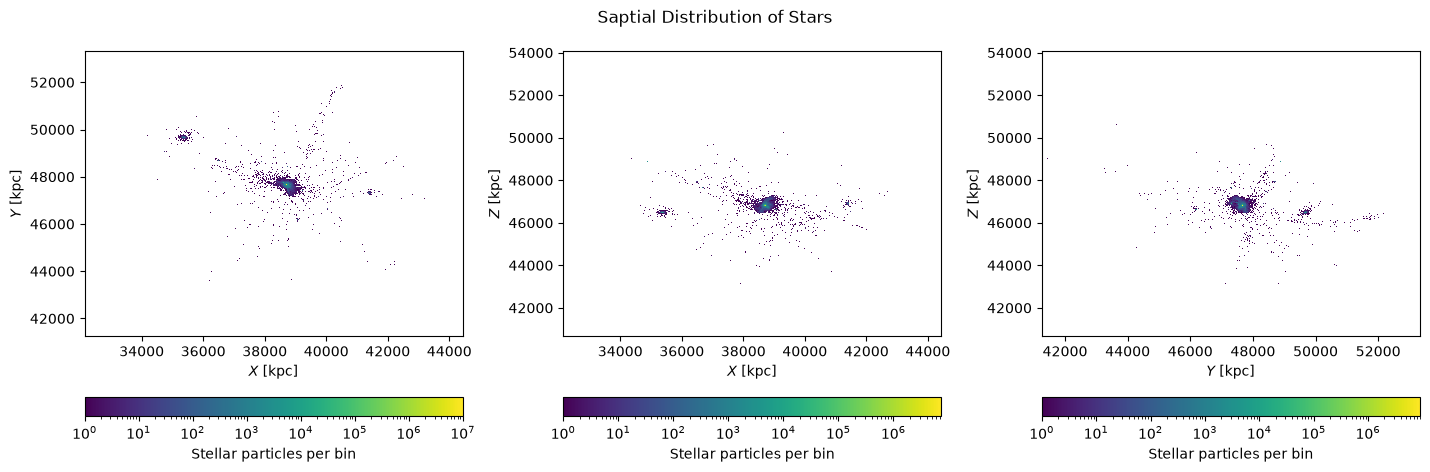

In [ ]:
# Exercise 02: Visualize the spatial distribution of the 3D coordinates

plt.figure(figsize=(4.8*3, 4.8), layout='tight')
plt.suptitle("Spatial Distribution of Stars")
bins = 1024

plt.subplot(1, 3, 1) 
plt.hist2d(coords[:, 0], coords[:, 1], 
           bins=bins, norm=LogNorm(), cmap='viridis')
plt.colorbar(label='Stellar particles per bin', orientation='horizontal')
plt.xlabel('$X$ [kpc]')
plt.ylabel('$Y$ [kpc]')

plt.subplot(1, 3, 2)
plt.hist2d(coords[:, 0], coords[:, 2], 
           bins=bins, norm=LogNorm(), cmap='viridis')
plt.colorbar(label='Stellar particles per bin', orientation='horizontal')
plt.xlabel('$X$ [kpc]')
plt.ylabel('$Z$ [kpc]')

plt.subplot(1, 3, 3)
plt.hist2d(coords[:, 1], coords[:, 2], 
           bins=bins, norm=LogNorm(), cmap='viridis')
plt.colorbar(label='Stellar particles per bin', orientation='horizontal')
plt.xlabel('$Y$ [kpc]')
plt.ylabel('$Z$ [kpc]')
plt.show()

#### Observations
I observe three distinct components in the system:
- The main body of the galaxy, which contains the majority of the stellar mass concentrated at the center.
- Two smaller, denser regions located farther out, likely representing expelled or stripped gas. \
These outer structures could result from past dynamical interactions, or feedback processes.
The central region exhibits the highest stellar density, indicating that most stars remain gravitationally bound within the galactic core.

Text(0, 0.5, 'Count')

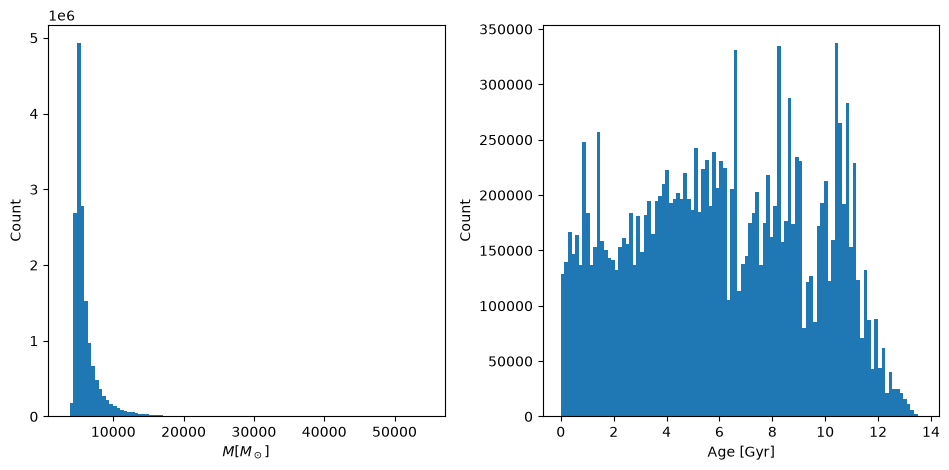

In [42]:
# Excercise 03: Plot the histogram of the age and mass distribution

plt.figure(figsize=(4.8*2, 4.8), layout='tight')
bins = 1024

plt.subplot(1, 2, 1)
plt.hist(masses, bins=100)
plt.xlabel(r'$M [M_\odot$]')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(ages, bins=100)
plt.xlabel(r'Age [Gyr]')
plt.ylabel('Count')

#### Observations
The typical range is b/w several thousand solar masses because mass and 
stellar lifetime are inversely related. Massive stars live short life, and thus never
accumulate enough numbers to be the more dominant mass range. 


Reason 01: Older stars (age 12 - 13 Gyr) are dead. \
Reason 02: The initial conditions of the galaxy probably only allowed a slow SFR. \
Reason 03: The peak at approx. 11 Gyr suggests the SFR suddenly increased, probably caused by a galactic merger

## Step 2: Centering and rotating the galaxy

Adequate visualization is important. Also important is the ability to work cleanly with the data. To ensure this, we must set a convenient reference system.

---

#### Problems:

The dominant structure is the synthetic galaxy of interest, **m12f**. In order to adequately study this galaxy we need to perform a suitable transformation of coordinates.

#### Fixing the galaxy
We need to center the spatial and velocity coordinates of the galaxy and subsequentially rotate them. To do so, apply the following transformations:
\begin{align}
    \vec{X}_\mathrm{new} &= \left( \vec{X} - \vec{X}_\mathrm{center} \right) M_\mathrm{rot} \\
    \vec{V}_\mathrm{new} &= \left( \vec{V} - \vec{V}_\mathrm{center} \right) M_\mathrm{rot}
\end{align}

Where:
\begin{align}
    \vec{X}_\mathrm{center} &= 38711.76 ~\vec{e}_x + 47665.05 ~\vec{e}_y + 46817.27 ~\vec{e}_z ~\mathrm{kpc} \\
    \vec{V}_\mathrm{center} &= -156.30017 ~\vec{e}_x + 161.67867 ~\vec{e}_y + 106.15526 ~\vec{e}_z ~\mathrm{km ~s^{-1}}
\end{align}
are the translation position and velocity vectors. The rotation matrix is given by:
\begin{align}
    M_\mathrm{rot} = 
    \begin{pmatrix}
    -0.57680130 & 0.36204576  & 0.73227257 \\
    -0.61994851 & 0.38972691  & -0.68101156 \\
    -0.53194368 & -0.84677964 & -0.00034525615
    \end{pmatrix}
\end{align}

For historical reasons, we shall orient the galaxy such that the stars follow a clockwise orbit, when seen face-on from top to bottom. To ensure this is the case, we calculate the angular momentum, $L_z$. If $L_z > 0$, then we negate the $\mathcal{O}_Z$ axis and the entire velocity vector. Since this is the case for this galaxy (optional: prove it), apply the following transformations:

\begin{align}
    Z_\mathrm{new}  &\rightarrow -Z_\mathrm{new}  \\
    \vec{V}_\mathrm{new}  &\rightarrow -\vec{V}_\mathrm{new}
\end{align}

    
#### Plot
1. Plot the results! You should obtain coordinate plots showing the galaxy face-on and edge-on.


#### Bonus
1. We can infer whether the galaxy has a singular disk or more by fitting one more power laws to the stellar count distribution in the vertical coordinate.
    1. Define a function "exponential", $f(z, a, b) = a \exp(-z/b)$, where $z$ is the vertical coordinate of the star count, $a$ is an amplitude and $b$ is a scale height.
    2. Define a function "exponential2" which combines two exponentials, $f(z, a_1, b_1, a_2, b_2) = a_1 \exp(-z/b_1) + a_2 \exp(-z/b_2)$, where $a_1, a_2$ are amplitudes and $b_1, b_2$ are scale heights.
    3. Select all stars within $\sqrt{X_\mathrm{Gal}^2 + Y_\mathrm{Gal}^2} < 8.2 ~\mathrm{kpc}$ and $|Z_\mathrm{Gal}| < 4  ~\mathrm{kpc}$.
    4. Fit one exponential to the selected stars and plot the results, including the scale height. Repeat for two exponentials. What do you conclude? Make a residual plot to back up your conclusions.

---

#### Hints:

In computer science, a **mask** or bitmask is data that is used for bitwise operations, particularly in a bit field. You can define a boolean array (i.e., where the elements are **True** or **False**) and impose this upon your data to select which data to keep and which data to discard. Wherever the mask is True will preserved the data, whereever the mask is False will remove the data. For example:

    mask = (radius < 8.2) & (age < 1)
    masked_coordinates = coordinates[mask]
    

- This is easier than it looks. Just follow the instructions and you'll be fine.
- If you are stuck on this step then I will provide you with the center of mass coordinates, center of mass velocities and the rotation matrix. However, it would be a good show of your skills if you were able to complete this step.

In [43]:
# Excercise 01(a): Coordinate Transformation

# Defining host position and velocity vectors and defining units 
host_position = np.array([38711.76, 47665.05, 46817.27]) * yt.units.kpc
host_velocity = np.array([-156.30017, 161.67867, 106.15526])*yt.units.km/yt.units.s

# Defining rotation matrix
host_rotation = np.array([
    [-0.57680130, 0.36204576, 0.73227257],
    [-0.61994851, 0.38972691, -0.68101156],
    [-0.53194368, -0.84677964, -0.00034525615]
])

# Coordinate and velocity transfomation 
XYZ = (coords - host_position) @ host_rotation.T
Vel = (velocities - host_velocity) @ host_rotation.T

In [44]:
# Defining spherical radius, cylindrical radius, and abs. Z

R = np.sqrt(XYZ[:, 0]**2 + XYZ[:, 1]**2 + XYZ[:, 2]**2)
r = np.sqrt(XYZ[:, 0]**2 + XYZ[:, 1]**2)
Z_abs = abs(XYZ[:,2])

In [45]:
# Optional: Verify whether L_Z > 0 for m21f or not

# Calculating linear momentum
PX = masses*Vel[:,0]
PY = masses*Vel[:,1]
PZ = masses*Vel[:,2]

# Taking transpose so that P's shape is (N, 3)
P = np.array([PX,PY,PZ]).T

# L = r  x p
L = np.cross(XYZ, P)

L_tot = np.sum(L,axis = 0)
print(L_tot[2])

# Excercise 01(b): Invert Z coord. and velocities
if L_tot[2]>0:
    XYZ[:, 2] = -XYZ[:, 2]
    Vel[:, 0] = -Vel[:, 0]
    Vel[:, 1] = -Vel[:, 1]
    Vel[:, 2] = -Vel[:, 2]

12307965436404.055 kpc


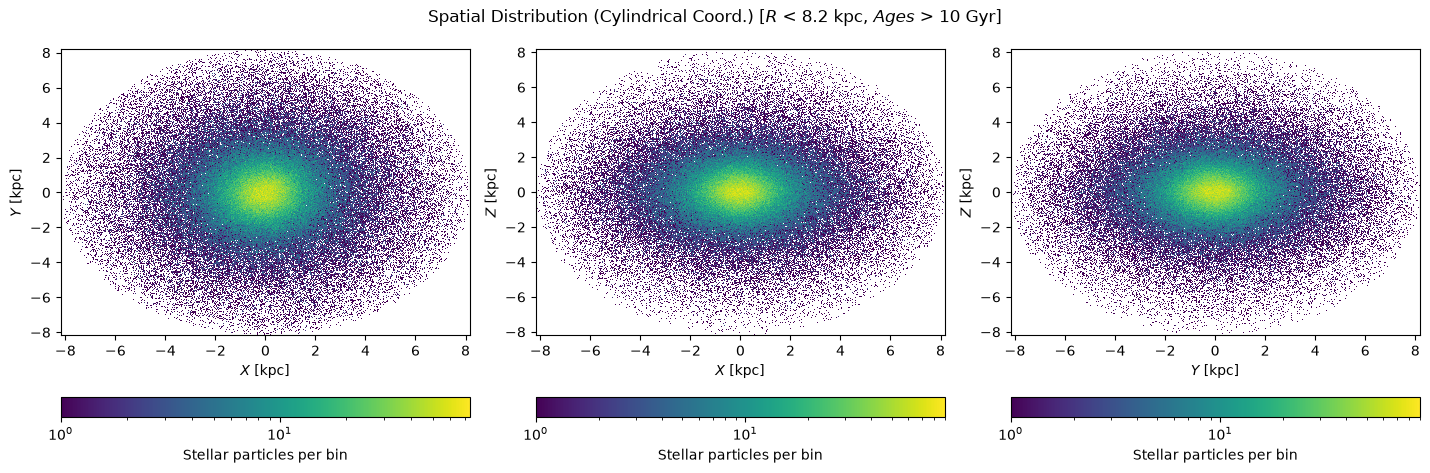

In [46]:
# Excercise 01(c): Plot spatial dist. in new co-ordinates

mask = (R < 8.2) & (ages > 10)

plt.figure(figsize=(4.8*3, 4.8), layout='tight')
plt.suptitle("Spatial Distribution (Cylindrical Coord.) [$R$ < 8.2 kpc, $Ages$ > 10 Gyr]" )
bins = 1024

plt.subplot(1, 3, 1)
plt.hist2d(
    XYZ[:, 0][mask], 
    XYZ[:, 1][mask], 
    bins=bins, 
    norm=LogNorm(), 
    cmap='viridis'
)
plt.colorbar(label='Stellar particles per bin', orientation='horizontal')
plt.xlabel('$X$ [kpc]')
plt.ylabel('$Y$ [kpc]')

plt.subplot(1, 3, 2)
plt.hist2d(
    XYZ[:, 0][mask], 
    XYZ[:, 2][mask], 
    bins=bins, 
    norm=LogNorm(), 
    cmap='viridis'
)
plt.colorbar(label='Stellar particles per bin', orientation='horizontal')
plt.xlabel('$X$ [kpc]')
plt.ylabel('$Z$ [kpc]')

plt.subplot(1, 3, 3)
plt.hist2d(
    XYZ[:, 1][mask], 
    XYZ[:, 2][mask], 
    bins=bins, 
    norm=LogNorm(), 
    cmap='viridis'
)
plt.colorbar(label='Stellar particles per bin', orientation='horizontal')
plt.xlabel('$Y$ [kpc]')
plt.ylabel('$Z$ [kpc]')
plt.show()

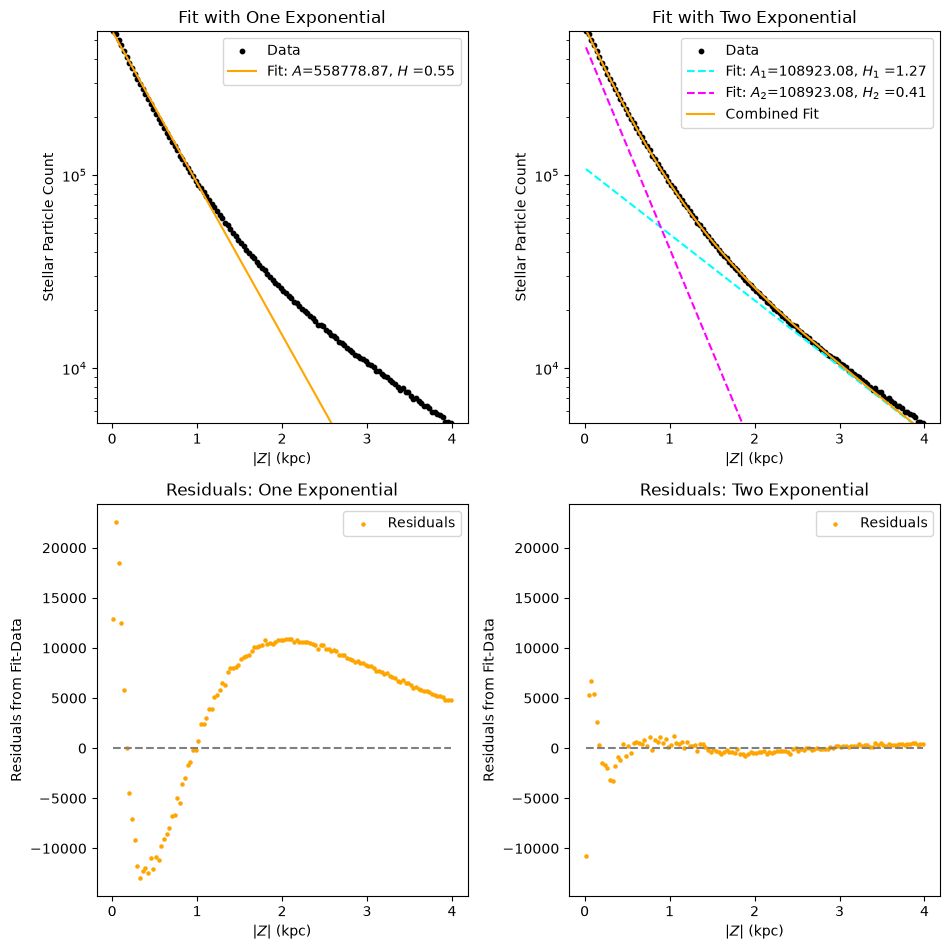

In [47]:
# Bonus: Fit exponential curves to the stellar particle number density

from scipy.optimize import curve_fit

# Define the exponential function
def exponential(x, a, b): 
    return a * np.exp(-x / b)

def exponential2(x, a1, b1, a2, b2):
    return a1 * np.exp(-x / b1) + a2 * np.exp(-x / b2)

# Masking to select relevant data points
mask = (r < 8.2) & (Z_abs < 4)
Z = XYZ[:,2]
z_sel = Z[mask]

# Making histrogram of vertical distribution to get Z count and bin ranges
bins = 128
h, bin_edges = np.histogram(np.abs(z_sel), bins=bins, density=False)
z_ticks = 0.5*(bin_edges[:-1] + bin_edges[1:]) 

plt.figure(figsize=(4.8*2, 4.8*2), layout='tight')

# Plotting and fitting for one exponential
plt.subplot(2,2,1)
popt1, _ = curve_fit(exponential, z_ticks, h, p0=(1, 1), bounds=([0, 0], [np.inf, np.inf]))
A_fit, H_fit = popt1

plt.scatter(z_ticks, h, color='k', label='Data', s=10)
plt.plot(z_ticks, exponential(z_ticks, *popt1), color='orange', label=f'Fit: $A$={A_fit:.2f}, $H$ ={H_fit:.2f}')
plt.title("Fit with One Exponential")
plt.xlabel('|$Z$| (kpc)')
plt.ylabel('Stellar Particle Count')
plt.yscale('log')
plt.ylim(min(h),max(h))
plt.legend()

# Plotting residuals for one exponential fit
plt.subplot(2,2,3)
residuals1 = h - exponential(z_ticks, *popt1)
plt.scatter(z_ticks, residuals1, color='orange', s=5, label = 'Residuals')
plt.hlines(0, min(z_ticks), max(z_ticks), ls='--', color='gray', )
plt.title("Residuals: One Exponential")
plt.xlabel('|$Z$| (kpc)')
plt.ylabel('Residuals from Fit-Data')
res_ylims = plt.ylim()
plt.legend()

# Plotting and fitting for two exponentials
plt.subplot(2,2,2)
popt2, _ = curve_fit(exponential2, z_ticks, h, p0=(popt1[0], popt1[1], popt1[0], popt1[1]), bounds=([0, 0, 0, 0], [np.inf]*4))
A1_fit, H1_fit, A2_fit, H2_fit = popt2

plt.scatter(z_ticks, h, color='k', label='Data', s=10)
plt.plot(z_ticks, exponential(z_ticks, A1_fit, H1_fit), color='cyan', ls='--', label=f'Fit: $A_1$={A1_fit:.2f}, $H_1$ ={H1_fit:.2f}')
plt.plot(z_ticks, exponential(z_ticks, A2_fit, H2_fit), color='magenta', ls='--', label=f'Fit: $A_2$={A1_fit:.2f}, $H_2$ ={H2_fit:.2f}')
plt.plot(z_ticks, exponential2(z_ticks, *popt2), color='orange', label='Combined Fit')
plt.title("Fit with Two Exponential")
plt.xlabel('|$Z$| (kpc)')
plt.ylabel('Stellar Particle Count')
plt.yscale('log')
plt.ylim(min(h),max(h))
plt.legend()

# Plotting residuals for two exponential fit
plt.subplot(2,2,4)
residuals2 = h - exponential2(z_ticks, *popt2)
plt.scatter(z_ticks, residuals2, color='orange', s=5, label='Residuals')
plt.hlines(0, min(z_ticks), max(z_ticks), ls='--', color='gray')
plt.title("Residuals: Two Exponential")
plt.xlabel('|$Z$| (kpc)')
plt.ylabel('Residuals from Fit-Data')
plt.ylim(res_ylims)
plt.legend()

#### Observations
The two-exponential fit matches the observed data significantly better than the single-exponential model,
as evidenced by the reduced residuals. This suggests the presence of two distinct stellar populations
or structural components—most likely corresponding to a thin and a thick disk in the galaxy.

## Step 3: Galactic Kinematics

---

#### Theoretical background:

In Newtonian mechanics, the kinetic energy is given by:
\begin{equation}
    T_\mathrm{Newton} = \frac{1}{2} m v^2
\end{equation}
whereas in special relativity the kinetic energy is instead given by:
\begin{equation}
    T_\mathrm{SR} = (\gamma - 1)mc^2
\end{equation}
where $c$ is the speed of light and $\gamma$ is the Lorentz factor, defined as:
\begin{equation}
    \gamma = \frac{1}{\sqrt{1 - \frac{v^2}{c^2}}}
\end{equation}
Depending on the velocity, it may be necessary to take into account relativistic effects. Suppose you have an object travelling at 1% the speed of light, $v = 0.01c = 3000$ km/s. What is the percentual difference between the Newtonian kinetic energy and the special relativity kinetic energy? Use the following formula:
\begin{equation}
    \frac{T_\mathrm{Newton} - T_\mathrm{SR}}{T_\mathrm{SR}}
\end{equation}
Is the difference significant enough (e.g. greater than 1%) to warrant relativistic considerations? Do you expect stellar particles to be travelling at speeds higher or lower than $0.01c$?

---

#### Problems:

1. You have the velocities in cartesian coordinates. Obtain the velocities in cylindrical coordinates, $\{ U, V, W \}$. **Note:** Because the majority of the disk stars are rotating clockwise, the prograde motion $V$ will be negative. By convention we want these to be positive, so invert the sign when calculating $V$. To be in line with the left-handed convention, invert also the sign of $U$, such that the radial velocity vector points inwards.
    1. $U$ is the radial velocity.
    2. $V$ is the azimuthal velocity.
    3. $W$ is the perpendicular velocity.
2. Plot the Toomre diagram of the **m12f** galaxy (consider $R_\mathrm{Gal} < 30$ kpc).
    1. Describe what you see. Are there any velocity tendencies?
    2. What are the tendency of the azimuthal velocities?
    3. What does it mean when $V < 0$ km/s?

---

#### Bonus:

Recall Newton's law of universal gravitation:
\begin{equation}
    F = G \frac{m M}{r^2}
\end{equation}
where $G$ is the gravitational constant and $r$ is the distance between the two masses, $m$ and $M$. For Newtonian circular orbital motion we have:
\begin{equation}
    F = \frac{m v^2}{r}
\end{equation}
where $v$ is the orbital velocity. Let $m$ be the mass of a stellar particle, $M$ the mass of the galaxy contained within the orbit of the stellar particle and $r$ the distance from the stellar particle and the galaxy's center of mass. Combining both equations gives us the expression for the orbital velocities of Keplerian orbits:
\begin{equation}
    v = \sqrt{\frac{GM}{r}}
\end{equation}

1. Compute the predicted Keplerian orbital velocities for the stellar particles as a function of cylindrical galactic radius, $v = v(R_\mathrm{Gal})$.
    1. Do so for $\sqrt{X_\mathrm{Gal}^2 + Y_\mathrm{Gal}^2} < 15 ~\mathrm{kpc}$ and $|Z_\mathrm{Gal}| < 1 ~\mathrm{kpc}$
    2. What is the predicted Keplerian velocity at an orbit of approximately $R_\mathrm{Gal} = 8.2$ kpc?
    3. Are these velocities Newtonian or relativistic?
2. Compare this with the real rotation curve, $V = V(R_\mathrm{Gal})$.
    1. Do the predictions match the observations?
    2. What's the azimuthal velocity at $R_\mathrm{Gal} = 8.2$ kpc?
    3. What's the explanation for the discrepancy between prediction and reality?

---

#### Hint:

- You should conclude that you do not need to take special relativity into account. Show your work.
- You should conclude that the predicted and observed galactic rotation curves do not match.

In [48]:
# Bonus: Kinematic Regime

# Defining functions to calculate T_Newt, T_SR, and their rel. difference.
def t_sr(m, v, c):
    gemma = 1/np.sqrt(1 - (v/c)**2)
    return (gemma - 1)*m*c**2
    
def t_newt(m,v):
    return 0.5*m*(v**2)

def t_rel_diff(t_newt, t_sr):
    return np.abs(((t_newt - t_sr)/t_sr))
    
# Defining some constants to test effects at v = 0.01c  
c = 300000 * yt.units.km/yt.units.s
v = 0.01*c
m = 1

print(f'The percentage difference b/w the two K.Es at v = 0.01c is {t_rel_diff(t_newt(m,v),t_sr(m,v,c)).value}%')
print('This is much smaller than 0.01%, so we can consider Newtonian regime forv < 0.01c ')

The percentage difference b/w the two K.Es at v = 0.01c is 7.50006266942516e-05%
This is much smaller than 0.01%, so we can consider Newtonian regime forv < 0.01c 


In [49]:
# Calculating velocity
vel_abs = np.sqrt(Vel[:,0]**2 + Vel[:,1]**2 + Vel[:,2]**2)


# Calculating both Ts for all particles
T_Newt = t_newt(masses, vel_abs)
T_SR = t_sr(masses, vel_abs, c)

# Calculating difference
T_Rel_Diff = t_rel_diff(T_Newt, T_SR)
median_t_diff = np.median(abs(T_Rel_Diff)) 
max_t_diff = np.max(abs(T_Rel_Diff))

print(f'The median relative difference in K.Es is: {median_t_diff.value:} and the maximum relative difference is {max_t_diff.value}')

The median relative difference in K.Es is: 4.516006543810601e-07 and the maximum relative difference is 0.0007694424069555869


In [50]:
# Excercise 01: Obtain the velocities in cylindrical coordinates

phi = np.arctan2(XYZ[:,1], XYZ[:,0])

# Inverting sign for U and V  due to left-hand convention
vel_U = -(Vel[:,0]*np.cos(phi)+ Vel[:,1]*np.sin(phi)) #radial
vel_V = -(-Vel[:,0]*np.sin(phi)+ Vel[:,1]*np.cos(phi)) # azimuthal
vel_W = Vel[:,2].copy() # perpendicular

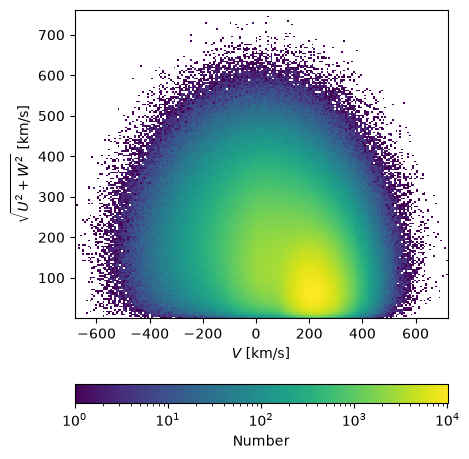

In [51]:
# Excercise 02: Plot the Toomre diagram of the m12f galaxy (consider R < 30 kpc)
mask = (R < 30)

plt.figure(figsize = (4.8,4.8), layout = 'tight')
bins = 200

plt.hist2d(vel_V[mask], np.sqrt(vel_U[mask]**2 + vel_W[mask]**2), bins = bins, norm = LogNorm())
plt.colorbar(label = 'Number', orientation = 'horizontal')
plt.xlabel('$V$ [km/s]')
plt.ylabel('$\\sqrt{U^2 + W^2}$ [km/s]')
plt.show()

#### Observations

A. In the Toomre diagram, most stars have positive azimuthal velocities,meaning they orbit in the clockwise direction. These stars also have low  values of radial and/or perpedicular velocities, indicating small random motions and that they are likely part of main disk. 

Stars with higher u or w velocities tend to have azimuthal velocities near zero or even negative, suggesting they are part of a kinematically different disk.

B. What are the tendencies of the azimuthal velocities? Most stars exhibit positive azimuthal velocities, indicating a general clockwise rotation characteristic of a disk-supported system.

C. What does it mean when V < 0 km/s? V < 0 km/s indicates a retrograde orbit, meaning the star is rotating in the anti-clockwise direction, opposite to the main stellar disk.

In [52]:
# Bonus: Compare observed and predicted rotation curve, especially for R = 8.2 kpc

# Creating general mask
mask_gen = (r < 15) & (Z_abs < 1)

# Number of r-points for which to calculate v_kepler
r_bins = 120

# Creating radial bins/segments for v_mean and v_kepler
r_bin_range = np.linspace(0, 15, r_bins+1) 

# Initializing arrays for storing v_mean and v_kepler
v_mean = np.zeros(r_bins)
v_kepler = np.zeros(r_bins)

G = 6.6743e-11

# Calculating and storing v values bin wise
for i in range(r_bins):
    # Mask for selecting observed velocities only in bin range to take their mean
    mask_v = (r > r_bin_range[i]) & (r < r_bin_range[i+1])
    v_mean[i] = np.mean(vel_V[mask_gen & mask_v]) 

    # Mask for summing total m enclosed in r = r_bin_range[i+1]
    mask_m = (r > r_bin_range[0]) & (r < r_bin_range[i+1])
    mass = np.sum(masses[mask_gen & mask_m])*1.989e30 # Convert to kg
    radius = r_bin_range[i+1]*3.086e19 # convert to m

    # Calculating and storing 
    v_kepler[i] = np.sqrt(G*mass/radius)*1e-3 #convert to km

At R = 8.25 kpc ≈ 8.2:
Predicted Keplerian velocity = 164.35 km/s
Mean observed velocity = 216.23 km/s


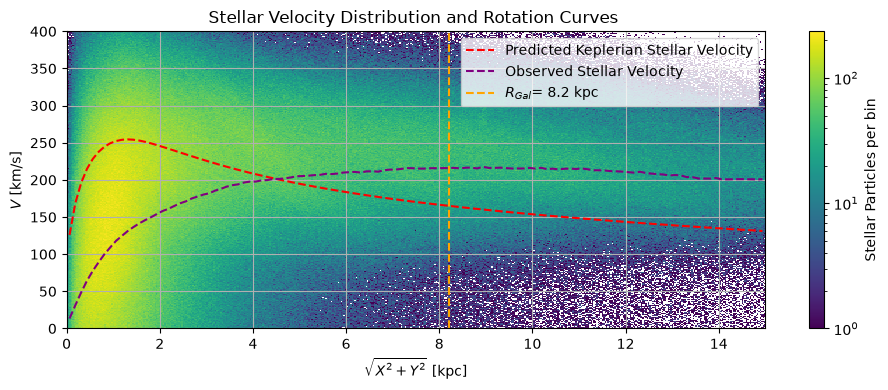

In [54]:
# Find the index of the bin closest to R = 8.2 kpc
target_r = 8.2
i_closest = np.argmin(np.abs(r_bin_range - target_r))

# Printing corresponding velocities
print(f"At R = {r_bin_range[i_closest]:.2f} kpc ≈ 8.2:")
print(f"Predicted Keplerian velocity = {v_kepler[i_closest]:.2f} km/s")
print(f"Mean observed velocity = {v_mean[i_closest]:.2f} km/s")


# Plotting rotation curves
plt.figure(figsize=(4.8*2,4), layout = 'tight')
hist_bins = 500

# x-axis r (mid-bin) values
# v_mean and v_kepler will be plotted against this
XY = 0.5 * (r_bin_range[:-1] + r_bin_range[1:])

# Velocity mask selects stars with 0 < V < 400 km/s, where stellar density is highest
# R < 30 kpc limits the sample to reduce crowding and improve visibilityy 
mask_v = (vel_V > 0) & (vel_V < 400) & (R < 30) 

plt.hist2d(r[mask_gen & mask_v].value, vel_V[mask_gen & mask_v].value, bins = hist_bins, norm = LogNorm())
plt.colorbar(label = 'Stellar Particles per bin')
plt.plot(XY, v_kepler, color = 'red', ls = '--', label = 'Predicted Keplerian Stellar Velocity')
plt.plot(XY, v_mean, color = 'purple', ls = '--', label = 'Observed Stellar Velocity')
plt.vlines(8.2, 0, 400, colors = 'orange', ls= '--', label='$R_{Gal}$= 8.2 kpc')
plt.title('Stellar Velocity Distribution and Rotation Curves ')
plt.xlabel('$\\sqrt{X^2 + Y^2}$ [kpc]')
plt.ylabel('$V$ [km/s]')
plt.legend(loc = 'best')
plt.grid(True)
plt.xlim(0,15)
plt.ylim(0,400)
plt.show()

#### Observations
1A. These velocities are Newtonian since,
(a) Both the Keplerian and observed velocities are calculated using classical mechanics.
(b) < 0.01c

2A. The Keplerian rotation curve does not match the observed one. It overestimates velocity for R < 4 kpc and underestimates it for R > 4 kpc.

2C. The discrepancy arises probably due to extra mass contribution at large r - like dark matter - which is not included in the Keplerian model.

## Step 4: Chemical Content

In the data you'll find the parameters **metallicity**, **He_metallicity**, **Mg_metallicity** and **Fe_metallicity**. These provide:
- Metallicity: The mass fraction for all "metals" (in astronomy all elements besides hydrogen and helium are considered metals), also referred to as $Z$
- He_metallicity: Helium mass fraction, also referred to as $Y$
- Mg_metallicity: Magnesium mass fraction
- Fe_metallicity: Iron mass fraction

The hydrogen mass fraction, $X$, can be obtained from the relation:
\begin{equation}
    X + Y + Z = 1
\end{equation}

These mass fractions can then be converted into abundance ratios and compared with the solar values. The equation to do so is:
\begin{equation}
    \left[ \frac{X_i}{X_j} \right] = \log_{10} \left( \frac{X_i}{X_j} \right) - A_{i, \odot} + A_{j, \odot} - \log_{10} \left( \frac{At_i}{At_j} \right)
\end{equation}
where $X_i$ and $X_j$ refer to the mass fractions of elements $i$ and $j$, $A_{i, \odot} $ refers to the solar abundance of the element $i$ and $At_i$ refers to the atomic weight of the element $i$. You may use the following values:
\begin{align}
    A_{H, \odot}  &= 12.00   \\
    A_{Mg, \odot} &= 7.60    \\
    A_{Fe, \odot} &= 7.50    \\
    At_{H}  &= 1    \\
    At_{Mg} &= 24   \\
    At_{Fe} &= 56   \\
\end{align}

These abundance ratios are compared with the solar values. For example, [Fe/H] = 0 means an iron over hydrogen abundance equal to that of the Sun, whereas [Fe/H] = -1.0 means that this abundance ratio is 10 times lower than that of the Sun.

---

#### Problems:
1. Obtain the hydrogen mass fraction, $X$.
2. Obtain the follwoing chemical abundance ratios and plot their histograms:
    1. [Fe/H]
    2. [Mg/H]
    3. [Mg/Fe]
3. Plot [Fe/H] as a function of stellar age. Do the same for [Mg/H] and [Mg/Fe].
    1. What is the evolutionary tendency for each abundance ratio?
        1. Do they increase or decrease?
        2. Is the behavior monotonic?
        3. Would you say there is evidence for more than a single chemical evolutionary path?
4. Plot a 2D histogram of [Mg/Fe] as a function of [Fe/H].
    1. Can you identify regions of high chemical dispersion? What about regions of tight chemical dispersion?
    1. Zoom in on regions of interest. Would you say there is a single chemical evolutionary path or multiple?

---

#### Hints:

- There is no need for hints, you have all the information you need.

In [55]:
# Excercise 01: Obtain hydrogen mass fraction
met = ds.all_data()["PartType4", "metallicity"].copy()
He_met = ds.all_data()["PartType4", "He_metallicity"].copy()
H_met = 1 - met - He_met

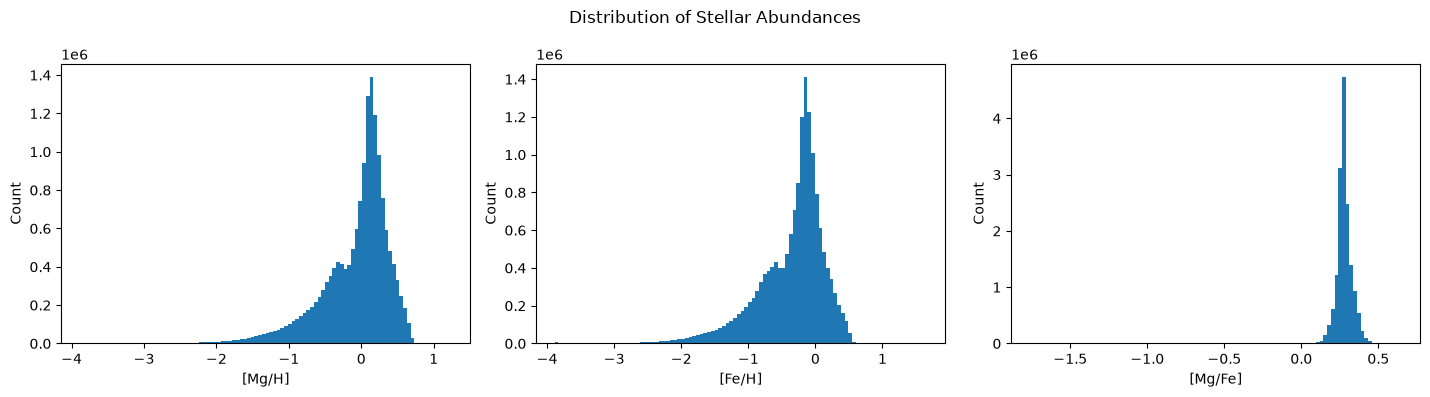

In [56]:
# Excercise 02: Obtain diff. chemical abundances and plot their hists

# Obtaining metallicity
Mg_met = ds.all_data()["PartType4", "Mg_metallicity"].copy()
Fe_met = ds.all_data()["PartType4", "Fe_metallicity"].copy()

# Abundances and Atomic Weights
A_H = 12
A_Mg = 7.60
A_Fe = 7.50

At_H = 1
At_Mg = 24
At_Fe = 56

# Calculating abundance ratios
MgH = np.log10(Mg_met/H_met) - A_Mg + A_H - np.log10(At_Mg/At_H)
FeH = np.log10(Fe_met/H_met) - A_Fe + A_H - np.log10(At_Fe/At_H)
MgFe =  MgH - FeH

# Plotting
plt.figure(figsize = (4.8*3,4), layout = "tight")
plt.suptitle('Distribution of Stellar Abundances')

plt.subplot(1,3,1)
plt.hist(MgH, bins = 100)
plt.xlabel('[Mg/H]')
plt.ylabel('Count')

plt.subplot(1,3,2)
plt.hist(FeH, bins = 100)
plt.xlabel('[Fe/H]')
plt.ylabel('Count')

plt.subplot(1,3,3)
plt.hist(MgFe, bins = 100)
plt.xlabel('[Mg/Fe]')
plt.ylabel('Count')
plt.show()

C:\Users\marya\AppData\Local\Temp\ipykernel_22112\674543836.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


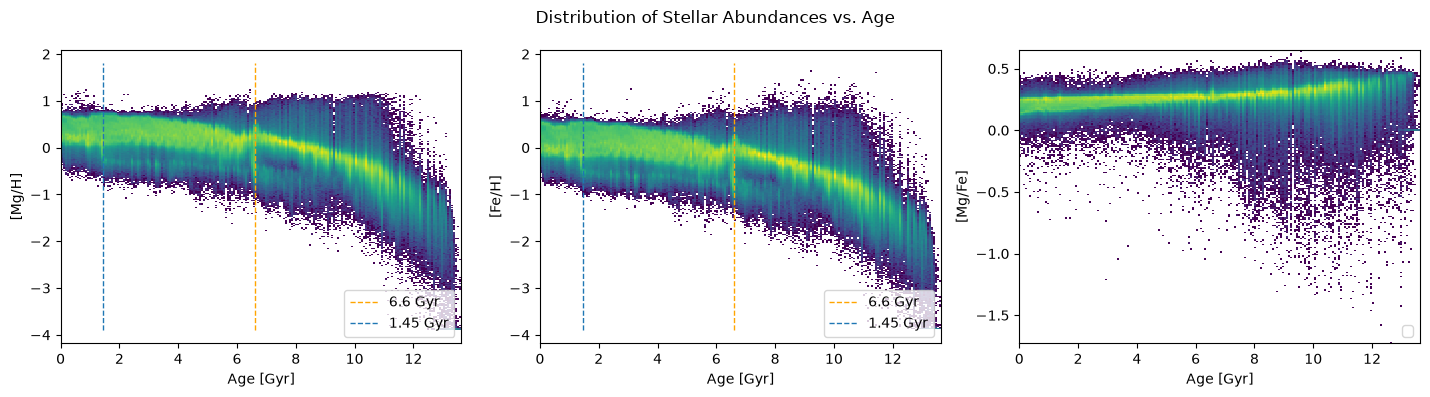

In [ ]:
# Excercise 03: Plot abundance ratios as a function of stellar age. 

mask_ab = (r < 15) & (Z_abs < 2)

plt.figure(figsize = (4.8*3,4), layout = 'tight')
plt.suptitle('Distribution of Stellar Abundances vs. Age')
bins = 200

plt.subplot(1,3,1)
plt.hist2d(np.array(ages[mask_ab]), MgH[mask_ab], bins = bins, norm = LogNorm())
plt.vlines(6.6, -3.9, 1.8, colors='orange', ls='--', lw = 1, alpha = 1, label='6.6 Gyr')
plt.vlines(1.45, -3.9, 1.8, ls='--', lw = 1, alpha = 1, label='1.45 Gyr')
plt.xlabel('Age [Gyr]')
plt.ylabel('[Mg/H]')
plt.legend(loc='lower right')

plt.subplot(1,3,2)
plt.hist2d(np.array(ages[mask_ab]), FeH[mask_ab], bins = bins, norm = LogNorm())
plt.vlines(6.6, -3.9, 1.8, colors='orange', ls='--', lw = 1, alpha = 1, label='6.6 Gyr')
plt.vlines(1.45, -3.9, 1.8, ls='--', lw = 1, alpha = 1, label='1.45 Gyr')
plt.xlabel('Age [Gyr]')
plt.ylabel('[Fe/H]')
plt.legend(loc='lower right')

plt.subplot(1,3,3)
plt.hist2d(np.array(ages[mask_ab]), MgFe[mask_ab], bins = bins, norm = LogNorm())
#plt.vlines(6.6, -3.9, 1.8, colors='orange', ls='--', lw = 1, alpha = 1, label='6.6 Gyr')
#plt.vlines(1.45, -3.9, 1.8, ls='--', lw = 1, alpha = 1, label='1.45 Gyr')
plt.xlabel('Age [Gyr]')
plt.ylabel('[Mg/Fe]')
#plt.legend(loc='lower right')

plt.show()

Evolutionary Trends of Abundance Ratios:

Both [Mg/H] and [Fe/H] show a general increase over time, consistent with the chemical evolution of a galaxy.
As more generations of stars form and die, they enrich the interstellar medium with heavier elements.
The overall trend is a monotonic increase, although there is a slight dip around ~6 Gyr,
possibly due to an episode of mass ejection or suppressed star formation.

There appears to be a dominant evolutionary track and a fainter secondary one beneath it,
suggesting the presence of multiple stellar populations — potentially indicating different disks,
a merger event, or distinct star formation histories.

[Mg/Fe], on the other hand, shows a monotonic decrease over time. This is expected:
Mg is produced primarily by short-lived, massive stars that explode early in the galaxy’s. 
Fe, in contrast, is largely produced by even more massive stars and by Type Ia supernovae,
which occur on longer timescales. As the galaxy evolves and more Fe accumulates,
the [Mg/Fe] ratio declines, reflecting the growing dominance of Fe-enrichment over time

<Figure size 640x480 with 0 Axes>

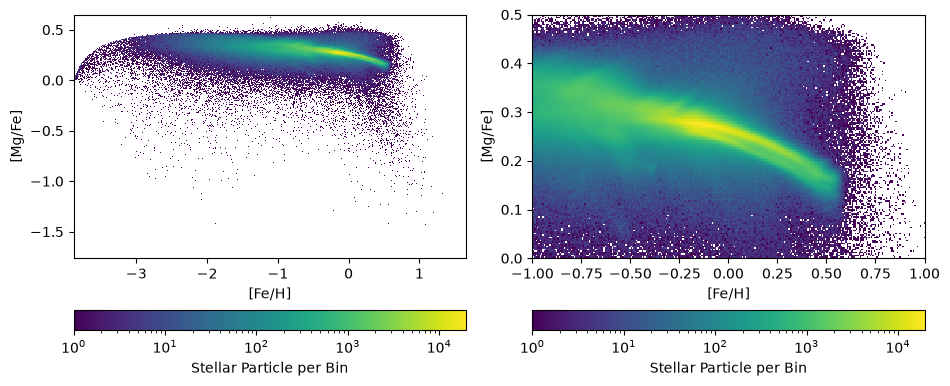

In [60]:
# Excercise 04: Plot a 2D histogram of [Mg/Fe] as a function of [Fe/H]

plt.suptitle('[Mg/Fe] vs. [Fe/H] Distribution')

plt.figure(figsize = (4.8*2,4), layout = 'tight')
bins = 800
plt.subplot(1,2,1)
plt.hist2d(np.array(FeH), np.array(MgFe), bins = bins, norm =LogNorm())
plt.colorbar(label = 'Stellar Particle per Bin', orientation = 'horizontal')
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')

# Zoomed in plot
plt.subplot(1,2,2)
plt.hist2d(np.array(FeH), np.array(MgFe), bins = bins, norm =LogNorm())
plt.colorbar(label = 'Stellar Particle per Bin', orientation = 'horizontal')
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1,1)
plt.ylim(0,0.5)
plt.show()

#### Observations
There seem to be  mutiple evolutionary tracks [two bright yellow streaks].

## Step 5: Ages

The most critical parameter to determine the history of a galaxy is the age. Stellar ages provide a chronological picture of the geometric, kinematic and evolution of the galaxy, as well as indicating periods of abnormal stellar formation rates.

---

#### Exercises:

Assume $R_\mathrm{Gal} < 30 ~\mathrm{kpc}$.

1. Plot a histogram of the age distribution.
2. Compute a Gaussian kernel density estimate (KDE) of the age distribution and plot it.
    1. There are routines in SciPy which can do this.
3. Study the age distribution.
    1. Is the stellar formation constant over time?
    2. Are there periods of diminished stellar formation?
    3. Are there periods of increased stellar formation?
    4. Give an example of a process which can promote stellar formation and one which inhibits stellar formation.

---

#### Problems:

Assume $R_\mathrm{Gal} < 30 ~\mathrm{kpc}$.

1. The galaxy contains several retrograde stars (rotating in the opposite azimuthal direction as the majority of the stars). Select these stars and analyze their age and chemical distributions.
    1. How different are they from bulk of the galaxy's stars?

---

#### Bonus:

Assume $R_\mathrm{Gal} < 30 ~\mathrm{kpc}$.

1. We want to trace the chemical evolution path over time.
    1. Write a for loop with an age step interval $\Delta \mathrm{Age} = 0.1 ~\mathrm{Gyr}$
    2. For each step, compute the mean $\mathrm{[Fe/H]}$ and $\mathrm{[Mg/Fe]}$
        1. Plot on top of it the mean $\mathrm{[Fe/H]}$ and $\mathrm{[Mg/Fe]}$ for each interval of time.
        2. Infer the chronological properties of the chemical evolution. What's the overall tendency?
            1. Hint: using a median filter can help.

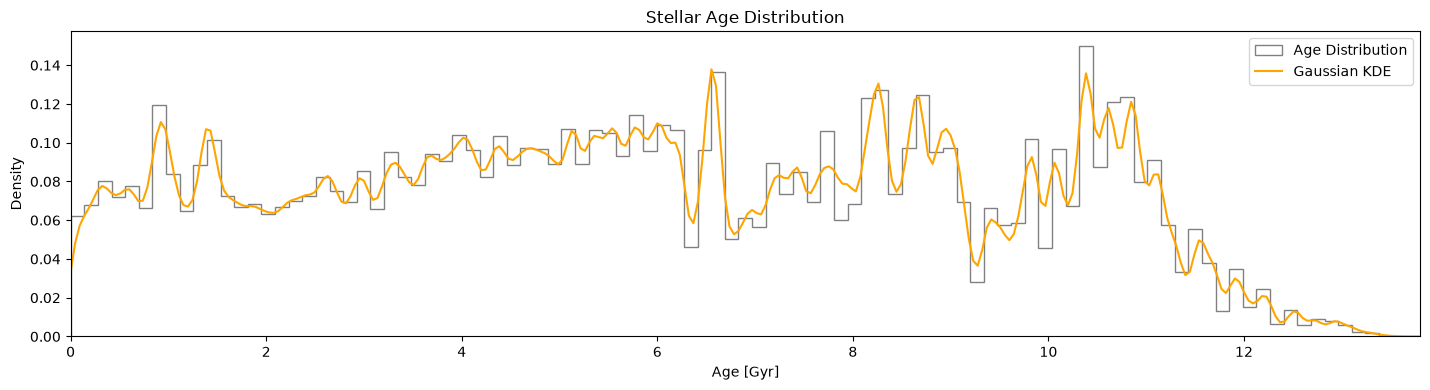

In [70]:
# Excercise 01 & 02: Plot age distribution and Gaussian kernel density estimate (KDE) of the age distribution 
from scipy import stats

# Maksing criteria 
mask_age = R < 30
ages_gyr = ages.to_value("Gyr")
# KDE
# Setting bandwidth to float for better control and avoding over-smoothing with 'scott' or 'silverman'
kernel = stats.gaussian_kde(ages[mask_age], bw_method = 0.02)
age_tick = np.linspace(0, 13.8, 300) # age of universe
density_tick = kernel(age_tick)

plt.figure(figsize = (4.8*3,4), layout = 'tight')
plt.hist(ages_gyr[mask_age], bins = np.linspace(0, 13.8, 100), histtype = 'step', color = 'gray', label = 'Age Distribution', density = True)
plt.plot(age_tick, density_tick, color = 'orange', label = 'Gaussian KDE')
plt.title('Stellar Age Distribution')
plt.xlabel('Age [Gyr]')
plt.ylabel('Density')
plt.legend(loc = 'best')
plt.xlim(0,13.8) 
plt.show()

- Stellar formation is not constant over time.
- Yes, there was likely a low SFR at the birth of mi12f (possibly due to the galaxy's initial mass function),
  and another dip around 9 Gyr ago, potentially caused by an external event such as quenching or matter ejection from a merger.
- Yes, there are at least 3 periods of increased SFR: between 10–11 Gyr ago, around 8 Gyrs ago, and again around 6–7 Gyrs ago.
- Events that can increase SFR include galaxy mergers, gas infall or rebound, and cooling of the interstellar medium.
  Events that decrease SFR include quenching mechanisms, gas ejection, or heating of the galactic environment.

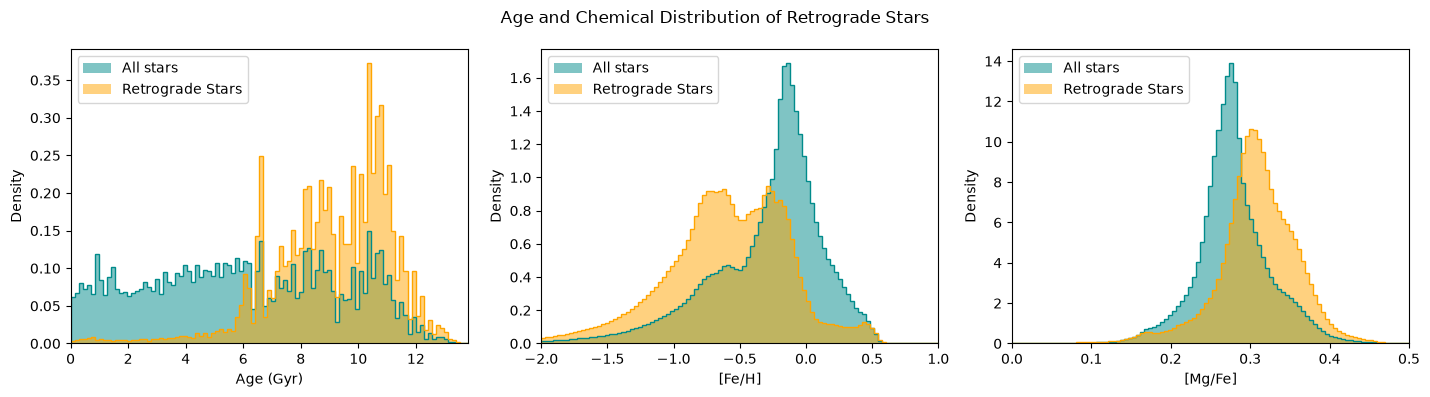

In [71]:
# Excercise 03: Age and chemical composition of retrograde stars

# Mask for selecting retrograde stars
mask_ret_v = vel_V < 0

plt.figure(figsize = (4.8*3,4), layout = 'tight')
plt.suptitle('Age and Chemical Distribution of Retrograde Stars')

plt.subplot(1,3,1)
bins = np.linspace(0, 13.8, 100)
plt.hist(ages_gyr[mask_age], bins = bins, histtype = 'stepfilled', color = 'darkcyan', alpha = 0.5, label = 'All stars', density = True)
plt.hist(ages_gyr[mask_age], bins = bins, histtype = 'step', color = 'darkcyan', density = True)
plt.hist(ages_gyr[mask_age & mask_ret_v], bins = bins, histtype = 'stepfilled', color = 'orange', alpha = 0.5, label = 'Retrograde Stars', density = True)
plt.hist(ages_gyr[mask_age & mask_ret_v], bins = bins, histtype = 'step', color = 'orange', density = True)
plt.xlabel('Age (Gyr)')
plt.ylabel('Density')
plt.xlim(min(bins), max(bins)) 
plt.legend(loc = 'best')

# Fe and Mg bins include denser distribution regions
plt.subplot(1,3,2)
bins = np.linspace(-2, 1, 100)
plt.hist(FeH[mask_age], bins = bins, histtype = 'stepfilled', color = 'darkcyan', alpha = 0.5, label = 'All stars', density = True)
plt.hist(FeH[mask_age], bins = bins, histtype = 'step', color = 'darkcyan', density = True)
plt.hist(FeH[mask_age & mask_ret_v], bins = bins, histtype = 'stepfilled', color = 'orange', alpha = 0.5, label = 'Retrograde Stars', density = True)
plt.hist(FeH[mask_age & mask_ret_v], bins = bins, histtype = 'step', color = 'orange', density = True)
plt.xlabel('[Fe/H]')
plt.ylabel('Density')
plt.xlim(min(bins), max(bins)) 
plt.legend(loc = 'best')

plt.subplot(1,3,3)
bins = np.linspace(0, 0.5, 100)
plt.hist(MgFe[mask_age], bins = bins, histtype = 'stepfilled', alpha = 0.5, color = 'darkcyan', label = 'All stars', density = True)
plt.hist(MgFe[mask_age], bins = bins, histtype = 'step', color = 'darkcyan', density = True)
plt.hist(MgFe[mask_age & mask_ret_v], bins = bins, histtype = 'stepfilled', alpha = 0.5, color = 'orange', label = 'Retrograde Stars', density = True)
plt.hist(MgFe[mask_age & mask_ret_v], bins = bins, histtype = 'step', color = 'orange', density = True)
plt.xlabel('[Mg/Fe]')
plt.ylabel('Density')
plt.xlim(min(bins), max(bins)) 
plt.legend(loc = 'best')
plt.show()

Retrograde stars in m12f have lower [Fe/H] and higher [Mg/H] ratios compared to the rest of the population.
They also constitute most of the oldest stars in the system. This suggests a distinct evolutionary history,
possibly resulting from an external event such as a past galaxy merger.

In [75]:
# Bonus: Trace the chemical evolution path over time

from scipy.ndimage import median_filter

# age bins spaced by 0.1Gyr
# oldest (13.8) to current (0)
age_bins = np.linspace(13.8, 0, 139)
mean_abundance = np.zeros((2, len(age_bins) - 1))

# calculating and storing mean abundace for bins
for i in range(len(age_bins) - 1):
    mask_bin = mask_age & ((ages > age_bins[i + 1]) & (ages < age_bins[i]))
    mean_abundance[0][i] = np.mean(FeH[mask_bin])
    mean_abundance[1][i] = np.mean(MgFe[mask_bin])


med_abn = median_filter(mean_abundance, size = (1,2))

c:\Users\marya\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\marya\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


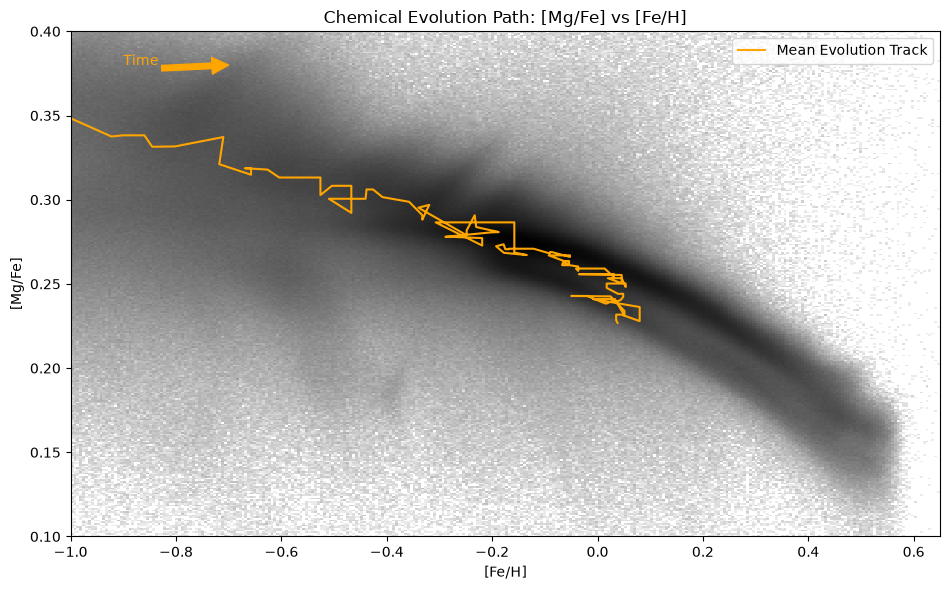

In [78]:
# Plotting 
plt.figure(figsize = (4.8*2, 4*1.5), layout = 'tight')
mask_comp = (FeH > -1) & (FeH < 0.65) & (MgFe > 0.1) & (MgFe < 0.4)
bins = 300

plt.hist2d(FeH[mask_comp], MgFe[mask_comp], bins = bins, norm = LogNorm(), cmap = 'binary')
plt.plot(med_abn[0], med_abn[1], color = 'orange', label='Mean Evolution Track')
plt.title('Chemical Evolution Path: [Mg/Fe] vs [Fe/H]')
plt.xlim(-1, 0.65)
plt.ylim(0.1, 0.4)
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')

# Add single arrow and label 
plt.annotate('Time', xy=(-0.7, 0.38), xytext=(-0.9, 0.38), fontsize=10, color='orange', arrowprops=dict(color='orange'))

plt.legend()
plt.show()

Over time, [Fe/H] increases while [Mg/Fe] decreases — a clear sign of chemical 
enrichment as the galaxy evolves.
- Loops in the evolution path ndicate bursts of SF, gas infall, or mergers.
- Turbulent phases